# Visualizer Notebook
### Just a helper notebook/snippets to print out images in NIFTI format
### As part of the Deep Learning course project

#### Background:
MRI images need to be stored in a non-compressable format so as not to cause any data loss nor require computational power to be read on the very weak medical devices whose hardware might not handle de-compressing large images.
Images should hold medical metadata.

The two widely used image formats are 1- DICOM (.dcm) and 2- NIFTI (.nii or .nii.gz)

 **Data preprocessing**

In [1]:
import os
import nibabel as nib
import numpy as np
import helpers

In [8]:
PROBLEM_TYPE = "CINE" #We must choose either of CINE or LGE (the LGE is just the same heart but injected with a material that enhances contrast)
IMAGE_TYPE = "4CH" #Available types are 2CH, 4CH and SAX (and additional RAS for LGE)

sample_n = 1 #Just change the number of the example sample from here
sample_n = str(sample_n).rjust(3, '0')


# I just made some boilerplate that reads directories based on the type of images
# Just change any path you want, but consider the aftermath of doing so (I hate my spaghetti coding skills)
DATASET_FOLDER_PATH = os.path.abspath(f".\\CMR-MULTI\\{PROBLEM_TYPE}_MULTI\\{IMAGE_TYPE}_TR\\image")
LABEL_FOLDER_PATH = os.path.abspath(f".\\CMR-MULTI\\{PROBLEM_TYPE}_MULTI\\{IMAGE_TYPE}_TR\\anno")


Sample_Train_NII_Path = os.path.join(DATASET_FOLDER_PATH, f"{PROBLEM_TYPE}_{IMAGE_TYPE}_{sample_n}.nii.gz") 
Sample_Mask_NII_Path = os.path.join(LABEL_FOLDER_PATH, f"{PROBLEM_TYPE}_{IMAGE_TYPE}_{sample_n}.nii.gz")


current_labels = helpers.load_labels(Problem_Type="CINE", Image_Type="4CH")

In [9]:
Example_Reading_Train_NII = nib.load(Sample_Train_NII_Path)
Example_Reading_Label_NII = nib.load(Sample_Mask_NII_Path)

print(type(Example_Reading_Train_NII))
print(Example_Reading_Train_NII) # general info

<class 'nibabel.nifti1.Nifti1Image'>

<class 'nibabel.nifti1.Nifti1Image'>
data shape (169, 155, 75)
affine:
[[-1.34537864e+00 -4.10289429e-02  5.43119910e-04  9.35487137e+01]
 [ 3.86571698e-02 -9.45912302e-01  8.50133747e-02  4.96412201e+01]
 [-2.43313946e-02  7.65808046e-01  1.05036080e-01 -7.71682434e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 169 155  75   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.        1.3461539 1.217742  0.1351301 1.        1.        1.
 1.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : u

In [10]:

img = nib.load(Sample_Train_NII_Path)
label = nib.load(Sample_Mask_NII_Path)

img_data = img.get_fdata()
label_data = label.get_fdata()

print("Image shape:", img_data.shape)
print("Label shape:", label_data.shape)



Image shape: (169, 155, 75)
Label shape: (169, 155, 75)


In [ ]:
import numpy as np
from skimage.transform import resize
from sklearn.preprocessing import RobustScaler


# -----------------------------
# 1) Cleaning: replace NaN values with 0
# -----------------------------
# This ensures that the model will not crash due to invalid values
img_data = np.nan_to_num(img_data)
label_data = np.nan_to_num(label_data)

# # -----------------------------
# # 2) Clipping: remove extreme outlier intensities
# # -----------------------------
# # We keep values between the 1st and 99th percentile
# p1, p99 = np.percentile(img_data, [1, 99])
# img_data = np.clip(img_data, p1, p99)

# # -----------------------------
# # 3) Normalization: scale image values to range [0, 1]
# # -----------------------------
# # This helps the neural network train more efficiently
# denominator = img_data.max() - img_data.min()

# if denominator != 0:
#     img_data = (img_data - img_data.min()) / denominator

# # -----------------------------
# # 4) Resize: make all images the same spatial size
# # -----------------------------
# # We keep the depth (number of slices) the same
# img_data = resize(
#     img_data,
#     (256, 256, img_data.shape[2]),
#     preserve_range=True
# )

# # For labels, we use order=0 to preserve class values
# label_data = resize(
#     label_data,
#     (256, 256, label_data.shape[2]),
#     order=0,
#     preserve_range=True
# )





# min-max scaler does not behave well with extreme outliers (z-score is better in this case)
# z-score scaler does not behave well with shifted distributions due to different camera vendors (robust scaler is better in this case)

# Using b2a the robust scaler :D
rbscaler = RobustScaler()
rbscaler = rbscaler.fit(helpers.recursive_flatten(helpers.get_all_images(DATASET_FOLDER_PATH)))



# -----------------------------
# 5) Datatype conversion
# -----------------------------
# float32 is standard for images in deep learning
# int32 is required for segmentation labels

img_data = img_data.astype(np.float32)
label_data = label_data.astype(np.int32)

print("Final image shape:", img_data.shape)
print("Final label shape:", label_data.shape)

Final image shape: (256, 256, 90)
Final label shape: (256, 256, 90)


In [18]:
#Check Normalization
print("Min:", img_data.min())
print("Max:", img_data.max())

Min: 0.0
Max: 1.0


In [19]:
#Check NaN
print("NaN in image:", np.isnan(img_data).any())
print("NaN in label:", np.isnan(label_data).any())

NaN in image: False
NaN in label: False


In [20]:
#Check Labels
print("Unique labels:", np.unique(label_data))

Unique labels: [0 1 2 3 4 5]


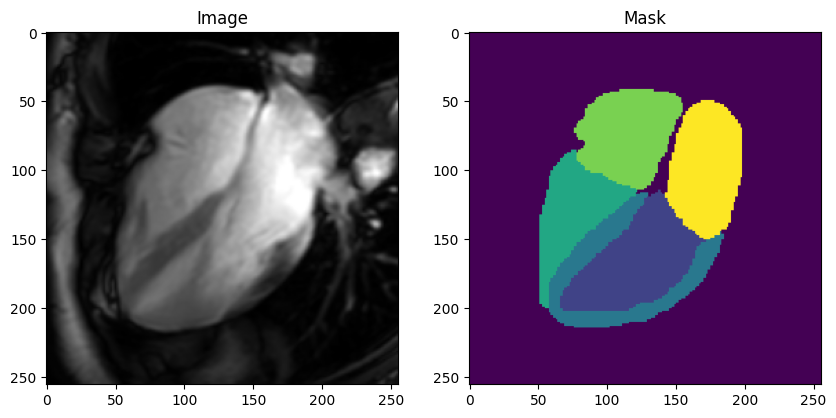

In [21]:
# Check visualization
import matplotlib.pyplot as plt

slice_idx = img_data.shape[2] // 2

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img_data[:, :, slice_idx], cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(label_data[:, :, slice_idx])

plt.show()

In [23]:
def Create_Dataset (nii_images_path, nii_masks_path, test_data_percentage=0.3):
    '''
    Dataset creator, it reads all files in the given pathes, converts them to tensors and returns 2 instances of torch.Datasets corresponding to a training set and a test set.

    :param nii_images_path: Path to the folder containing all images data
    :param nii_masks_path: Path to the folder containing all masked data
    :param test_data_percentage: Percentage of test set for splitting
    '''
    image_nii_files = os.listdir(os.path.abspath(nii_images_path))
    # I will just make each filename as an absolute path to avoid python errors
    image_nii_files = [os.path.join(os.path.abspath(nii_images_path), i) for i in image_nii_files]

    #same with mask images
    mask_nii_files = os.listdir(os.path.abspath(nii_masks_path))
    mask_nii_files = [os.path.join(os.path.abspath(nii_masks_path), i) for i in mask_nii_files]

    # For every file in the list of nii files, will convert it to a tensor and append them to a giant list
    list_image_tensors = []
    list_mask_tensors = []

    test_image_tensors = []
    test_mask_tensors = []

    for i, image_path in enumerate(image_nii_files):
        new_tensor = nii_to_tensor(image_path)
        list_image_tensors.append(new_tensor)

    for image_path in mask_nii_files:
        new_tensor = nii_to_tensor(image_path)
        list_mask_tensors.append(new_tensor)

    #sanity check, image tensors and mask tensors should be of equal number
    print(f"All dataset is of length {len(list_image_tensors)}", sep=None)
    print(f"With Masks of{len(list_mask_tensors)}")

    assert len(list_image_tensors) == len(list_mask_tensors)

    print(f"Splitting data to {1-test_data_percentage} for training and {test_data_percentage} for testing...")


    split_idx = int(len(list_image_tensors) * test_data_percentage)

    test_image_tensors = list_image_tensors[:split_idx]
    list_image_tensors = list_image_tensors[split_idx:]

    test_mask_tensors = list_mask_tensors[:split_idx]




    list_mask_tensors = list_mask_tensors[split_idx:]

    print(f"Training with {len(list_image_tensors)}:{len(list_mask_tensors)}")
    print(f"Testing with {len(test_image_tensors)}:{len(test_mask_tensors)}")

    return MRIDataset(list_image_tensors, list_mask_tensors),  MRIDataset(test_image_tensors, test_mask_tensors)





# Data_Path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\image\CINE_4CH_001.nii.gz"
# Label_Path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\anno\CINE_4CH_001.nii.gz"
# PROBLEM_TYPE = "CINE"
# IMAGE_TYPE="4CH"
# CMAP = "grey"

# image_saved_path = Path(Data_Path).name
# video_saved_path = Path(Label_Path).name
# frame_delay = 50




# #example usage
# visualize_nii_file("4CH", Data_Path, Label_Path)